# Serienindividuelle Filterung nach letzter Nachfrage

Dieses Notebook prüft, welche Store-Produkt-Reihen nach ihrer aktuellen letzten Nachfragepause historisch ungewöhnlich inaktiv wirken.

Vor der Lückenanalyse werden beide Datensätze auf Reihen mit mindestens `MIN_DEMAND_PERIODS_OVERALL` positiven Nachfragetagen über die vollständige beobachtete Reihe gefiltert. Der Wert wird oben im Notebook gesetzt und ist bewusst vom Modellselektions-Schwellenwert bis zum ersten Origin getrennt.

Untersuchte Datensätze:

- `data/processed/transactions_dst_over_days_fcm`
- `data/processed/transactions_dst_over_days`


## Definition

Eine Reihe ist eine eindeutige Kombination aus `MARKT_ID` und `ARTIKEL_ID`.

Für jede Reihe wird der letzte Verkaufstag als letzter Tag mit positiver Nachfrage berechnet: `ABVERKAUFTE_MENGE_KG > 0`. Das entspricht der Demand-Spalte, die auch in der Tagesverteilung als Startkriterium verwendet wird. Als Datenstand gilt der späteste Kalendertag im jeweiligen Datensatz, nicht der letzte Verkaufstag einer einzelnen Reihe.

Die aktuelle Lücke ist:

`Datenstand - letzter positiver Verkaufstag`

Die historischen Lücken einer Reihe sind:

`aktueller positiver Verkaufstag - vorheriger positiver Verkaufstag - 1 Tag`

Der Filter kombiniert zwei Regeln. Erstens wird eine Reihe entfernt, wenn der letzte Verkauf mehr als 100 Tage zurückliegt. Zweitens wird eine Reihe entfernt, wenn ihre aktuelle Lücke deutlich größer ist als die eigene historische Referenzlücke. Dadurch bleiben dauerhaft inaktive Reihen draußen, ohne für alle aktiven Produkte dieselbe starre Lückenstruktur zu unterstellen.

Die Kontrollausgabe für Reihen ohne positive Nachfrage wird separat auf der ungefilterten Basis berechnet, damit ein Fehler in der Tagesverteilung nicht durch den Mindestnachfrage-Filter verdeckt wird.


In [46]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent.parent
MIN_DEMAND_PERIODS_OVERALL = 10

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)

DATASETS = [
    {
        "Datensatz": "FCM täglich",
        "Pfad": ROOT / "data" / "processed" / "transactions_dst_over_days_fcm",
    },
    {
        "Datensatz": "Alle täglich",
        "Pfad": ROOT / "data" / "processed" / "transactions_dst_over_days",
    },
]

SALE_CONDITION = "COALESCE(ABVERKAUFTE_MENGE_KG, 0) > 0"
SERIES_COLUMNS = ["MARKT_ID", "ARTIKEL_ID"]

con = duckdb.connect()
_ = con.execute("PRAGMA threads=8")
_ = con.execute("SET preserve_insertion_order=false")


## Basis nach Mindestnachfrage-Filter

Die erste Tabelle zeigt, wie viele Reihen der Mindestnachfrage-Filter entfernt. Die zweite Tabelle beschreibt die verbleibenden Reihen, auf denen die weitere Lückenanalyse basiert.


In [47]:
def sql_string(value):
    return str(value).replace("'", "''")


def parquet_glob(directory):
    files = sorted(directory.glob("transactions_year_*.parquet"))
    if not files:
        raise FileNotFoundError(f"Keine Parquet-Dateien in {directory} gefunden")
    return sql_string(directory / "transactions_year_*.parquet")


def percent(part, total):
    return round(100 * part / total, 2) if total else 0.0


def load_series_sales(dataset):
    source = parquet_glob(dataset["Pfad"])
    return con.execute(
        f"""
        SELECT
            MARKT_ID,
            ARTIKEL_ID,
            MIN(CAST(DATE AS DATE)) AS erster_tag,
            MAX(CAST(DATE AS DATE)) AS letzter_tag,
            MIN(CASE WHEN {SALE_CONDITION} THEN CAST(DATE AS DATE) END) AS erster_verkauf,
            MAX(CASE WHEN {SALE_CONDITION} THEN CAST(DATE AS DATE) END) AS letzter_verkauf,
            COUNT(*)::BIGINT AS beobachtete_perioden,
            SUM(CASE WHEN {SALE_CONDITION} THEN 1 ELSE 0 END)::BIGINT AS nachfrageperioden,
            SUM(CASE WHEN {SALE_CONDITION} THEN UMS_MENGE ELSE 0 END) AS menge_summe,
            SUM(CASE WHEN {SALE_CONDITION} THEN ABVERKAUFTE_MENGE_KG ELSE 0 END) AS kg_summe,
            SUM(CASE WHEN {SALE_CONDITION} THEN UMS_VK_WERT ELSE 0 END) AS umsatz_summe
        FROM read_parquet('{source}')
        WHERE MARKT_ID IS NOT NULL
          AND ARTIKEL_ID IS NOT NULL
          AND DATE IS NOT NULL
        GROUP BY MARKT_ID, ARTIKEL_ID
        """
    ).fetchdf()


def apply_min_demand_filter(dataset, series_sales):
    keep_mask = series_sales["nachfrageperioden"] >= MIN_DEMAND_PERIODS_OVERALL
    kept = series_sales.loc[keep_mask].copy()
    removed = int((~keep_mask).sum())
    return kept, {
        "Datensatz": dataset["Datensatz"],
        "Pfad": dataset["Pfad"].relative_to(ROOT).as_posix(),
        "Mindest_Nachfragetage": MIN_DEMAND_PERIODS_OVERALL,
        "Reihen_vor_Filter": len(series_sales),
        "Reihen_nach_Filter": len(kept),
        "Reihen_entfernt": removed,
        "Anteil_entfernt_%": percent(removed, len(series_sales)),
    }


def days_since_last_sale(series_sales):
    data_stand = series_sales["letzter_tag"].max()
    return data_stand, (data_stand - series_sales["letzter_verkauf"]).dt.days


def summarize_dataset(dataset, series_sales):
    data_stand, days_since_sale = days_since_last_sale(series_sales)
    series_with_sale = series_sales["letzter_verkauf"].notna().sum()
    return {
        "Datensatz": dataset["Datensatz"],
        "Pfad": dataset["Pfad"].relative_to(ROOT).as_posix(),
        "Reihen_nach_Mindestfilter": len(series_sales),
        "Reihen_mit_Verkauf": int(series_with_sale),
        "Produkte": series_sales["ARTIKEL_ID"].nunique(),
        "Filialen": series_sales["MARKT_ID"].nunique(),
        "erster_Tag": series_sales["erster_tag"].min().date(),
        "Datenstand": data_stand.date(),
        "erster_Verkauf": series_sales["erster_verkauf"].min().date(),
        "Median_Tage_seit_letztem_Verkauf": float(days_since_sale.dropna().median()),
        "Max_Tage_seit_letztem_Verkauf": int(days_since_sale.dropna().max()),
    }


series_sales_raw_by_dataset = {}
series_sales_by_dataset = {}
min_demand_filter_rows = []
overview_rows = []

for dataset in DATASETS:
    raw_series_sales = load_series_sales(dataset)
    series_sales, min_demand_row = apply_min_demand_filter(dataset, raw_series_sales)

    series_sales_raw_by_dataset[dataset["Datensatz"]] = raw_series_sales
    series_sales_by_dataset[dataset["Datensatz"]] = series_sales
    min_demand_filter_rows.append(min_demand_row)
    overview_rows.append(summarize_dataset(dataset, series_sales))

min_demand_filter_summary = pd.DataFrame(min_demand_filter_rows)
dataset_overview = pd.DataFrame(overview_rows)

display(min_demand_filter_summary)
display(dataset_overview)

zero_sale_series = pd.concat(
    [
        series_sales.assign(Datensatz=name)
        for name, series_sales in series_sales_raw_by_dataset.items()
    ],
    ignore_index=True,
)
zero_sale_series = zero_sale_series[zero_sale_series["letzter_verkauf"].isna()]
zero_sale_series = zero_sale_series[
    [
        "Datensatz",
        "MARKT_ID",
        "ARTIKEL_ID",
        "erster_tag",
        "letzter_tag",
        "beobachtete_perioden",
        "nachfrageperioden",
        "menge_summe",
        "kg_summe",
        "umsatz_summe",
    ]
].sort_values(["Datensatz", "MARKT_ID", "ARTIKEL_ID"])

print("Kontrolle vor Mindestnachfragefilter: Reihen ohne positive Nachfrage")
display(zero_sale_series)


,Datensatz,Pfad,Mindest_Nachfragetage,Reihen_vor_Filter,Reihen_nach_Filter,Reihen_entfernt,Anteil_entfernt_%
0,FCM täglich,data/processed/transactions_dst_over_days_fcm,10,3667,2333,1334,36.38
1,Alle täglich,data/processed/transactions_dst_over_days,10,152646,105215,47431,31.07


,Datensatz,Pfad,Reihen_nach_Mindestfilter,Reihen_mit_Verkauf,Produkte,Filialen,erster_Tag,Datenstand,erster_Verkauf,Median_Tage_seit_letztem_Verkauf,Max_Tage_seit_letztem_Verkauf
0,FCM täglich,data/processed/transactions_dst_over_days_fcm,2333,2333,37,105,2025-04-17,2026-07-10,2025-04-17,6.0,314
1,Alle täglich,data/processed/transactions_dst_over_days,105215,105215,2734,110,2021-07-11,2026-07-10,2021-07-11,77.0,1813


Kontrolle vor Mindestnachfragefilter: Reihen ohne positive Nachfrage


,Datensatz,MARKT_ID,ARTIKEL_ID,erster_tag,letzter_tag,beobachtete_perioden,nachfrageperioden,menge_summe,kg_summe,umsatz_summe


## Quantile der aktuellen Lücken und historischen Lücken je Reihe

Die aktuelle Lücke ist der Abstand zwischen Datenstand und letztem positiven Verkaufstag einer Reihe. Damit die historischen Lücken vergleichbar sind, wird auch hier zuerst je Reihe eine Kennzahl gebildet. Die Tabelle zeigt die Verteilungen dieser Serienwerte nach dem Mindestnachfrage-Filter.


In [48]:
GAP_QUANTILES = {
    "Minimum": 0.00,
    "P10": 0.10,
    "P25": 0.25,
    "Median": 0.50,
    "P75": 0.75,
    "P90": 0.90,
    "P95": 0.95,
    "P99": 0.99,
    "Maximum": 1.00,
}


def load_historical_gap_days(dataset, eligible_series):
    source = parquet_glob(dataset["Pfad"])
    positive_days = con.execute(
        f"""
        SELECT
            MARKT_ID,
            ARTIKEL_ID,
            CAST(DATE AS DATE) AS verkaufstag
        FROM read_parquet('{source}')
        WHERE MARKT_ID IS NOT NULL
          AND ARTIKEL_ID IS NOT NULL
          AND DATE IS NOT NULL
          AND {SALE_CONDITION}
        GROUP BY MARKT_ID, ARTIKEL_ID, verkaufstag
        ORDER BY MARKT_ID, ARTIKEL_ID, verkaufstag
        """
    ).fetchdf()
    positive_days["verkaufstag"] = pd.to_datetime(positive_days["verkaufstag"])
    positive_days = positive_days.merge(
        eligible_series[SERIES_COLUMNS].drop_duplicates(),
        on=SERIES_COLUMNS,
        how="inner",
    )
    positive_days = positive_days.sort_values([*SERIES_COLUMNS, "verkaufstag"])
    positive_days["vorheriger_verkaufstag"] = positive_days.groupby(
        SERIES_COLUMNS,
        observed=True,
    )["verkaufstag"].shift()
    positive_days["historische_luecke_tage"] = (
        positive_days["verkaufstag"] - positive_days["vorheriger_verkaufstag"]
    ).dt.days - 1
    return positive_days.dropna(subset=["historische_luecke_tage"]).copy()


def summarize_historical_gaps_by_series(historical_gaps):
    return (
        historical_gaps.groupby(SERIES_COLUMNS, observed=True)
        .agg(
            historische_luecken=("historische_luecke_tage", "size"),
            mittlere_historische_luecke=("historische_luecke_tage", "mean"),
            median_historische_luecke=("historische_luecke_tage", "median"),
            p90_historische_luecke=(
                "historische_luecke_tage",
                lambda values: values.quantile(0.90),
            ),
            maximale_historische_luecke=("historische_luecke_tage", "max"),
        )
        .reset_index()
    )


def add_gap_quantile_row(rows, dataset_name, gap_type, values, series_count):
    values = pd.Series(values).dropna()
    row = {
        "Datensatz": dataset_name,
        "Lueckentyp": gap_type,
        "Reihen_nach_Mindestfilter": series_count,
        "Serienwerte_in_Verteilung": len(values),
    }
    for label, quantile in GAP_QUANTILES.items():
        row[label] = values.quantile(quantile) if not values.empty else pd.NA
    rows.append(row)


gap_quantile_rows = []
historical_gaps_by_dataset = {}
historical_gap_series_summary_by_dataset = {}

for dataset in DATASETS:
    series_sales = series_sales_by_dataset[dataset["Datensatz"]]
    _, current_gap_days = days_since_last_sale(series_sales)
    current_gap_days = current_gap_days.dropna()
    add_gap_quantile_row(
        gap_quantile_rows,
        dataset_name=dataset["Datensatz"],
        gap_type="Aktuelle Lücke seit letztem Verkauf",
        values=current_gap_days,
        series_count=len(series_sales),
    )

    historical_gaps = load_historical_gap_days(dataset, series_sales)
    historical_gap_series_summary = summarize_historical_gaps_by_series(historical_gaps)
    historical_gaps_by_dataset[dataset["Datensatz"]] = historical_gaps
    historical_gap_series_summary_by_dataset[dataset["Datensatz"]] = historical_gap_series_summary

    historical_summary_columns = {
        "Historische mittlere Lücke je Reihe": "mittlere_historische_luecke",
        "Historische Median-Lücke je Reihe": "median_historische_luecke",
        "Historische P90-Lücke je Reihe": "p90_historische_luecke",
        "Historische Maximallücke je Reihe": "maximale_historische_luecke",
    }
    for gap_type, column in historical_summary_columns.items():
        add_gap_quantile_row(
            gap_quantile_rows,
            dataset_name=dataset["Datensatz"],
            gap_type=gap_type,
            values=historical_gap_series_summary[column],
            series_count=len(series_sales),
        )

gap_quantiles = pd.DataFrame(gap_quantile_rows)
quantile_columns = list(GAP_QUANTILES)
display(
    gap_quantiles.style.format(
        {column: "{:.1f}" for column in quantile_columns},
        na_rep="",
    )
)


,Datensatz,Lueckentyp,Reihen_nach_Mindestfilter,Serienwerte_in_Verteilung,Minimum,P10,P25,Median,P75,P90,P95,P99,Maximum
0,FCM täglich,Aktuelle Lücke seit letztem Verkauf,2333,2333,0.0,0.0,1.0,6.0,50.0,107.8,127.0,289.0,314.0
1,FCM täglich,Historische mittlere Lücke je Reihe,2333,2333,0.1,0.7,1.2,2.8,5.8,10.0,13.3,27.0,40.8
2,FCM täglich,Historische Median-Lücke je Reihe,2333,2333,0.0,0.0,0.0,1.0,2.0,3.5,5.0,10.0,20.0
3,FCM täglich,Historische P90-Lücke je Reihe,2333,2333,0.2,2.0,3.0,6.0,12.8,24.8,32.9,62.0,110.0
4,FCM täglich,Historische Maximallücke je Reihe,2333,2333,1.0,6.0,12.0,28.0,54.0,90.0,105.0,241.0,280.0
5,Alle täglich,Aktuelle Lücke seit letztem Verkauf,105215,105215,0.0,1.0,4.0,77.0,542.0,1276.0,1508.0,1708.0,1813.0
6,Alle täglich,Historische mittlere Lücke je Reihe,105215,105215,0.1,0.9,2.1,6.1,18.5,45.6,70.9,125.0,198.4
7,Alle täglich,Historische Median-Lücke je Reihe,105215,105215,0.0,0.0,0.0,1.0,3.0,7.0,14.5,55.0,251.0
8,Alle täglich,Historische P90-Lücke je Reihe,105215,105215,0.0,2.0,4.3,11.0,34.2,108.1,192.5,353.8,787.9
9,Alle täglich,Historische Maximallücke je Reihe,105215,105215,1.0,10.0,24.0,103.0,268.0,451.0,647.3,1032.0,1689.0


## Lückenverteilungen

Die Grafiken vergleichen die aktuelle Lücke jeder Reihe mit historischen Serienkennzahlen. Die x-Achsen sind pro Datensatz separat skaliert, damit die Verteilungen lesbar bleiben.


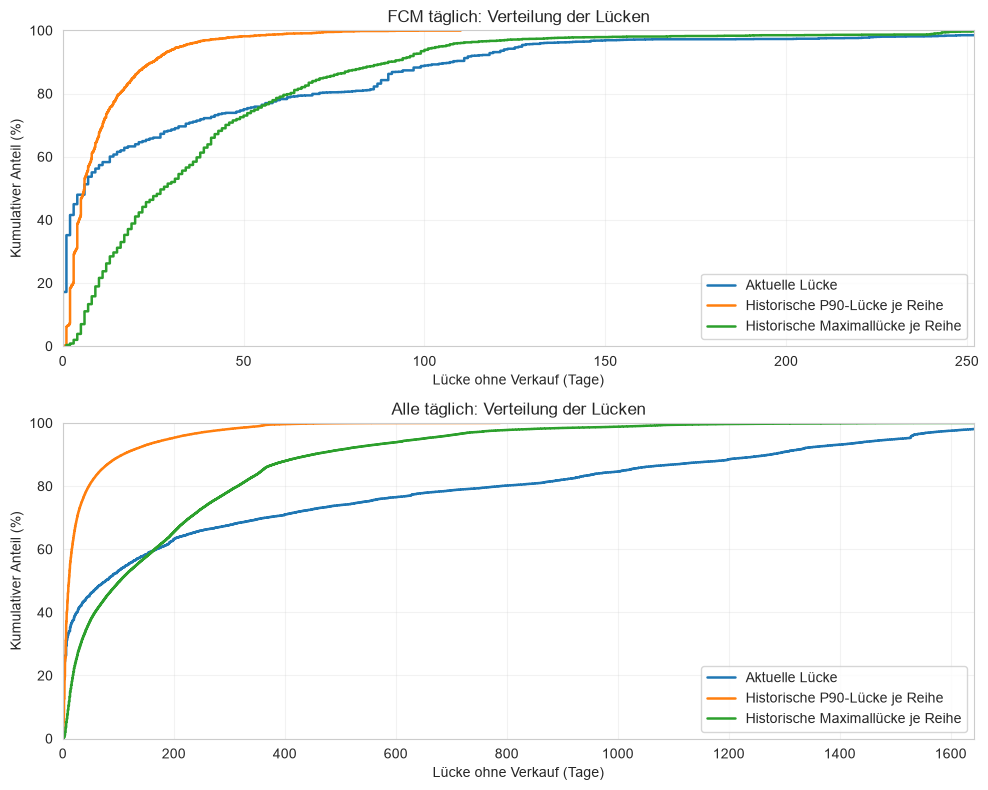

In [49]:
def ecdf(values):
    values = np.sort(pd.Series(values).dropna().to_numpy(dtype=float))
    if len(values) == 0:
        return values, values
    y = np.arange(1, len(values) + 1) / len(values) * 100
    return values, y


fig, axes = plt.subplots(len(DATASETS), 1, figsize=(10, 4 * len(DATASETS)), sharex=False)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    dataset_name = dataset["Datensatz"]
    series_sales = series_sales_by_dataset[dataset_name]
    _, current_gap_days = days_since_last_sale(series_sales)
    historical_summary = historical_gap_series_summary_by_dataset[dataset_name]

    plot_values = {
        "Aktuelle Lücke": current_gap_days,
        "Historische P90-Lücke je Reihe": historical_summary["p90_historische_luecke"],
        "Historische Maximallücke je Reihe": historical_summary["maximale_historische_luecke"],
    }
    for label, values in plot_values.items():
        x, y = ecdf(values)
        ax.step(x, y, where="post", linewidth=1.8, label=label)

    combined = pd.concat([pd.Series(values).dropna() for values in plot_values.values()])
    ax.set_xlim(0, max(1, combined.quantile(0.99) * 1.05))
    ax.set_ylim(0, 100)
    ax.set_title(f"{dataset_name}: Verteilung der Lücken")
    ax.set_xlabel("Lücke ohne Verkauf (Tage)")
    ax.set_ylabel("Kumulativer Anteil (%)")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

fig.tight_layout()
plt.show()


## Verteilung des Lückenfaktors

Der Lückenfaktor vergleicht die aktuelle Pause einer Reihe mit ihrer eigenen maximalen historischen Pause: `aktuelle Lücke / maximale historische Lücke`. Diese Verteilung macht sichtbar, wie streng der gewählte Faktor ist. Die vertikale Linie markiert den aktuell verwendeten Filterfaktor.


,Datensatz,Serienwerte_in_Verteilung,P50,P75,P80,P85,P90,P95,P99
0,FCM täglich,2333,0.22,1.23,1.87,2.35,3.05,5.21,35.54
1,Alle täglich,105215,0.39,3.88,7.63,17.03,37.82,85.22,284.77


,Datensatz,Faktor,Reihen_entfernt,Anteil_entfernt_%
0,FCM täglich,1.50,522,22.37
1,FCM täglich,2.00,434,18.60
2,FCM täglich,2.50,320,13.72
3,FCM täglich,3.00,239,10.24
4,FCM täglich,3.75,171,7.33
5,FCM täglich,4.00,161,6.90
6,FCM täglich,5.00,123,5.27
7,Alle täglich,1.50,34027,32.34
8,Alle täglich,2.00,31579,30.01
9,Alle täglich,2.50,29908,28.43


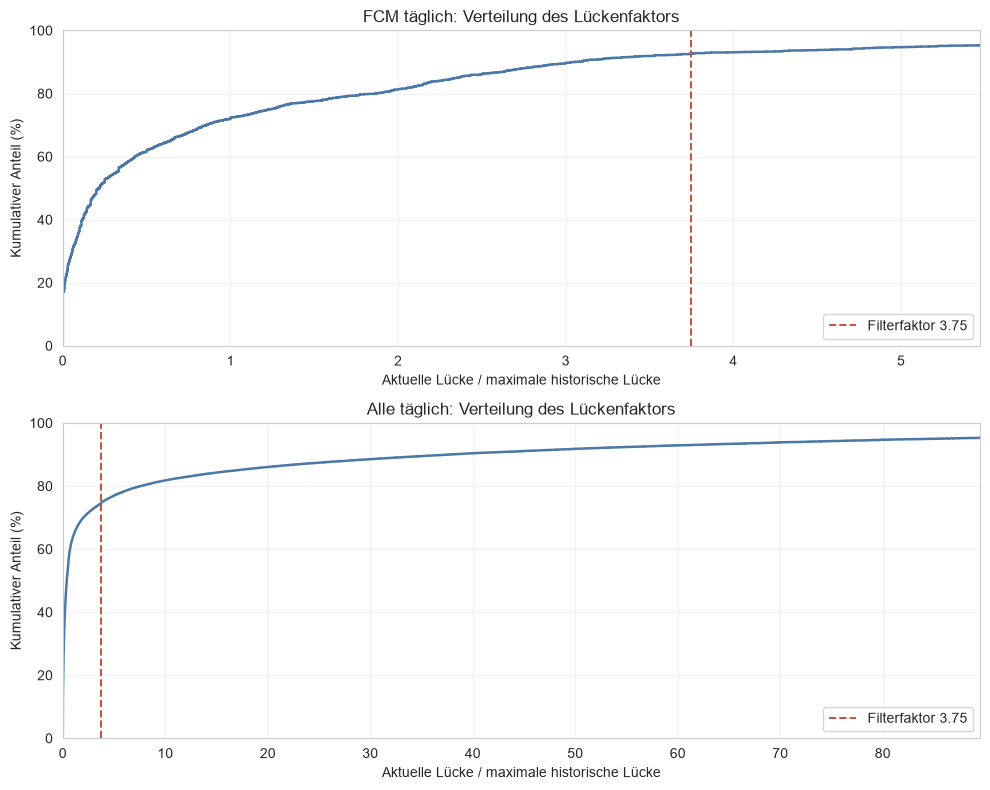

In [50]:
CURRENT_TO_HISTORICAL_GAP_FACTOR = 3.75
HISTORICAL_REFERENCE_COLUMN = "maximale_historische_luecke"
HISTORICAL_REFERENCE_LABEL = "maximale historische Lücke je Reihe"


def build_gap_factor_data(dataset):
    dataset_name = dataset["Datensatz"]
    series_sales = series_sales_by_dataset[dataset_name].copy()
    _, current_gap_days = days_since_last_sale(series_sales)
    series_sales["aktuelle_luecke_tage"] = current_gap_days
    series_sales["verkaufshistorie_tage"] = (
        series_sales["letzter_verkauf"] - series_sales["erster_verkauf"]
    ).dt.days

    historical_summary = historical_gap_series_summary_by_dataset[dataset_name]
    result = series_sales.merge(historical_summary, on=SERIES_COLUMNS, how="left")
    result["historische_referenz_luecke"] = result[HISTORICAL_REFERENCE_COLUMN]
    result["luecken_faktor"] = np.where(
        result["historische_referenz_luecke"] > 0,
        result["aktuelle_luecke_tage"] / result["historische_referenz_luecke"],
        np.where(result["aktuelle_luecke_tage"] > 0, np.inf, 0.0),
    )
    result["Datensatz"] = dataset_name
    return result


gap_factor_by_dataset = {
    dataset["Datensatz"]: build_gap_factor_data(dataset)
    for dataset in DATASETS
}

GAP_FACTOR_QUANTILES = {
    "P50": 0.50,
    "P75": 0.75,
    "P80": 0.80,
    "P85": 0.85,
    "P90": 0.90,
    "P95": 0.95,
    "P99": 0.99,
}

factor_quantile_rows = []
factor_threshold_rows = []
threshold_factors = sorted({1.5, 2.0, 2.5, 3.0, CURRENT_TO_HISTORICAL_GAP_FACTOR, 4.0, 5.0})

for dataset_name, frame in gap_factor_by_dataset.items():
    finite_factors = frame["luecken_faktor"].replace([np.inf, -np.inf], np.nan).dropna()
    quantile_row = {
        "Datensatz": dataset_name,
        "Serienwerte_in_Verteilung": len(finite_factors),
    }
    for label, quantile in GAP_FACTOR_QUANTILES.items():
        quantile_row[label] = finite_factors.quantile(quantile)
    factor_quantile_rows.append(quantile_row)

    for factor in threshold_factors:
        removed = int((frame["luecken_faktor"] > factor).sum())
        factor_threshold_rows.append({
            "Datensatz": dataset_name,
            "Faktor": factor,
            "Reihen_entfernt": removed,
            "Anteil_entfernt_%": percent(removed, len(frame)),
        })

factor_quantiles = pd.DataFrame(factor_quantile_rows)
factor_threshold_summary = pd.DataFrame(factor_threshold_rows)

display(
    factor_quantiles.style.format(
        {column: "{:.2f}" for column in GAP_FACTOR_QUANTILES},
    )
)
display(
    factor_threshold_summary.style.format({
        "Faktor": "{:.2f}",
        "Anteil_entfernt_%": "{:.2f}",
    })
)

fig, axes = plt.subplots(len(DATASETS), 1, figsize=(10, 4 * len(DATASETS)), sharex=False)
if len(DATASETS) == 1:
    axes = [axes]

for ax, dataset in zip(axes, DATASETS):
    dataset_name = dataset["Datensatz"]
    factors = gap_factor_by_dataset[dataset_name]["luecken_faktor"].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    x, y = ecdf(factors)
    ax.step(x, y, where="post", linewidth=1.8, color="#4c78a8")
    ax.axvline(
        CURRENT_TO_HISTORICAL_GAP_FACTOR,
        color="#c4513b",
        linestyle="--",
        linewidth=1.4,
        label=f"Filterfaktor {CURRENT_TO_HISTORICAL_GAP_FACTOR:g}",
    )
    ax.set_xlim(0, max(CURRENT_TO_HISTORICAL_GAP_FACTOR * 1.4, factors.quantile(0.95) * 1.05))
    ax.set_ylim(0, 100)
    ax.set_title(f"{dataset_name}: Verteilung des Lückenfaktors")
    ax.set_xlabel("Aktuelle Lücke / maximale historische Lücke")
    ax.set_ylabel("Kumulativer Anteil (%)")
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

fig.tight_layout()
plt.show()


## Serienindividueller Filter

Eine Reihe wird entfernt, wenn mindestens eine der beiden Bedingungen gilt:

- Der letzte Verkauf liegt mehr als `MAX_CURRENT_GAP_DAYS` Tage zurück. Diese Regel entfernt Reihen, die am Datenende bereits sehr lange keine Nachfrage mehr hatten.
- Die aktuelle Lücke ist größer als `CURRENT_TO_HISTORICAL_GAP_FACTOR * historische Referenzlücke`. Diese Regel entfernt Reihen, deren aktuelle Pause im Verhältnis zur eigenen Historie ungewöhnlich lang ist.

Die Ergebnistabelle trennt beide Gründe, damit sichtbar bleibt, ob Reihen wegen der absoluten 100-Tage-Grenze, wegen des serienindividuellen Faktors oder wegen beider Regeln entfernt werden.


In [51]:
MAX_CURRENT_GAP_DAYS = 100

individual_filter_by_dataset = {}
for dataset_name, frame in gap_factor_by_dataset.items():
    filtered_frame = frame.copy()
    filtered_frame["entfernen_wegen_aktueller_luecke"] = (
        filtered_frame["aktuelle_luecke_tage"] > MAX_CURRENT_GAP_DAYS
    )
    filtered_frame["entfernen_wegen_lueckenfaktor"] = (
        filtered_frame["aktuelle_luecke_tage"]
        > CURRENT_TO_HISTORICAL_GAP_FACTOR * filtered_frame["historische_referenz_luecke"]
    )
    filtered_frame["entfernen"] = (
        filtered_frame["entfernen_wegen_aktueller_luecke"]
        | filtered_frame["entfernen_wegen_lueckenfaktor"]
    )
    filtered_frame["Entfernungsgrund"] = np.select(
        [
            filtered_frame["entfernen_wegen_aktueller_luecke"]
            & filtered_frame["entfernen_wegen_lueckenfaktor"],
            filtered_frame["entfernen_wegen_aktueller_luecke"],
            filtered_frame["entfernen_wegen_lueckenfaktor"],
        ],
        [
            "aktuelle Lücke > 100 Tage und Lückenfaktor",
            "aktuelle Lücke > 100 Tage",
            "Lückenfaktor",
        ],
        default="behalten",
    )
    individual_filter_by_dataset[dataset_name] = filtered_frame

removed_series_by_dataset = {
    dataset_name: frame[frame["entfernen"]].copy()
    for dataset_name, frame in individual_filter_by_dataset.items()
}

individual_filter_summary = pd.DataFrame(
    [
        {
            "Datensatz": dataset_name,
            "Referenz": HISTORICAL_REFERENCE_LABEL,
            "Faktor": CURRENT_TO_HISTORICAL_GAP_FACTOR,
            "Max_aktuelle_Luecke_Tage": MAX_CURRENT_GAP_DAYS,
            "Reihen_nach_Mindestfilter": len(frame),
            "Reihen_mit_historischer_Referenz": int(frame["historische_referenz_luecke"].notna().sum()),
            "Reihen_entfernt_wegen_aktueller_Luecke": int(
                frame["entfernen_wegen_aktueller_luecke"].sum()
            ),
            "Reihen_entfernt_wegen_Lueckenfaktor": int(
                frame["entfernen_wegen_lueckenfaktor"].sum()
            ),
            "Reihen_entfernt_wegen_beider_Regeln": int(
                (
                    frame["entfernen_wegen_aktueller_luecke"]
                    & frame["entfernen_wegen_lueckenfaktor"]
                ).sum()
            ),
            "Reihen_entfernt": int(frame["entfernen"].sum()),
            "Anteil_entfernt_%": percent(int(frame["entfernen"].sum()), len(frame)),
            "Median_aktuelle_Luecke_entfernt": float(
                frame.loc[frame["entfernen"], "aktuelle_luecke_tage"].median()
            ),
            "Median_Faktor_entfernt": float(
                frame.loc[frame["entfernen"], "luecken_faktor"].replace(np.inf, np.nan).median()
            ),
        }
        for dataset_name, frame in individual_filter_by_dataset.items()
    ]
)

display(individual_filter_summary.style.format({
    "Faktor": "{:.2f}",
    "Anteil_entfernt_%": "{:.2f}",
    "Median_aktuelle_Luecke_entfernt": "{:.1f}",
    "Median_Faktor_entfernt": "{:.1f}",
}))


,Datensatz,Referenz,Faktor,Max_aktuelle_Luecke_Tage,Reihen_nach_Mindestfilter,Reihen_mit_historischer_Referenz,Reihen_entfernt_wegen_aktueller_Luecke,Reihen_entfernt_wegen_Lueckenfaktor,Reihen_entfernt_wegen_beider_Regeln,Reihen_entfernt,Anteil_entfernt_%,Median_aktuelle_Luecke_entfernt,Median_Faktor_entfernt
0,FCM täglich,maximale historische Lücke je Reihe,3.75,100,2333,2333,259,171,98,332,14.23,119.0,3.8
1,Alle täglich,maximale historische Lücke je Reihe,3.75,100,105215,105215,49220,26652,26355,49517,47.06,598.0,4.7


## Beispiele entfernter Reihen

Die Beispiele stammen aus entfernten FCM-Reihen mit mindestens 100 Tagen Verkaufshistorie. Sie werden über die Verteilung der aktuellen Lücken verteilt ausgewählt und müssen möglichst Abstand zueinander haben. Jede Reihe bekommt eine eigene x-Achse ab dem ersten Verkauf, damit die Zeitachsen lesbar bleiben.


,Beispiel,MARKT_ID,ARTIKEL_ID,aktuelle_luecke_tage,historische_referenz_luecke,luecken_faktor,Entfernungsgrund,verkaufshistorie_tage,nachfrageperioden
0,Beispiel 1,1100059,1413120,37,9,4.1,Lückenfaktor,126,57
16,Beispiel 2,1100087,1406590,88,23,3.8,Lückenfaktor,198,38
217,Beispiel 3,1300009,1382863,140,144,1.0,aktuelle Lücke > 100 Tage,174,14
238,Beispiel 4,1300027,1399512,191,35,5.5,aktuelle Lücke > 100 Tage und Lückenfaktor,133,26
249,Beispiel 5,1100038,1382863,244,55,4.4,aktuelle Lücke > 100 Tage und Lückenfaktor,183,28
251,Beispiel 6,1100031,1382788,295,12,24.6,aktuelle Lücke > 100 Tage und Lückenfaktor,111,41


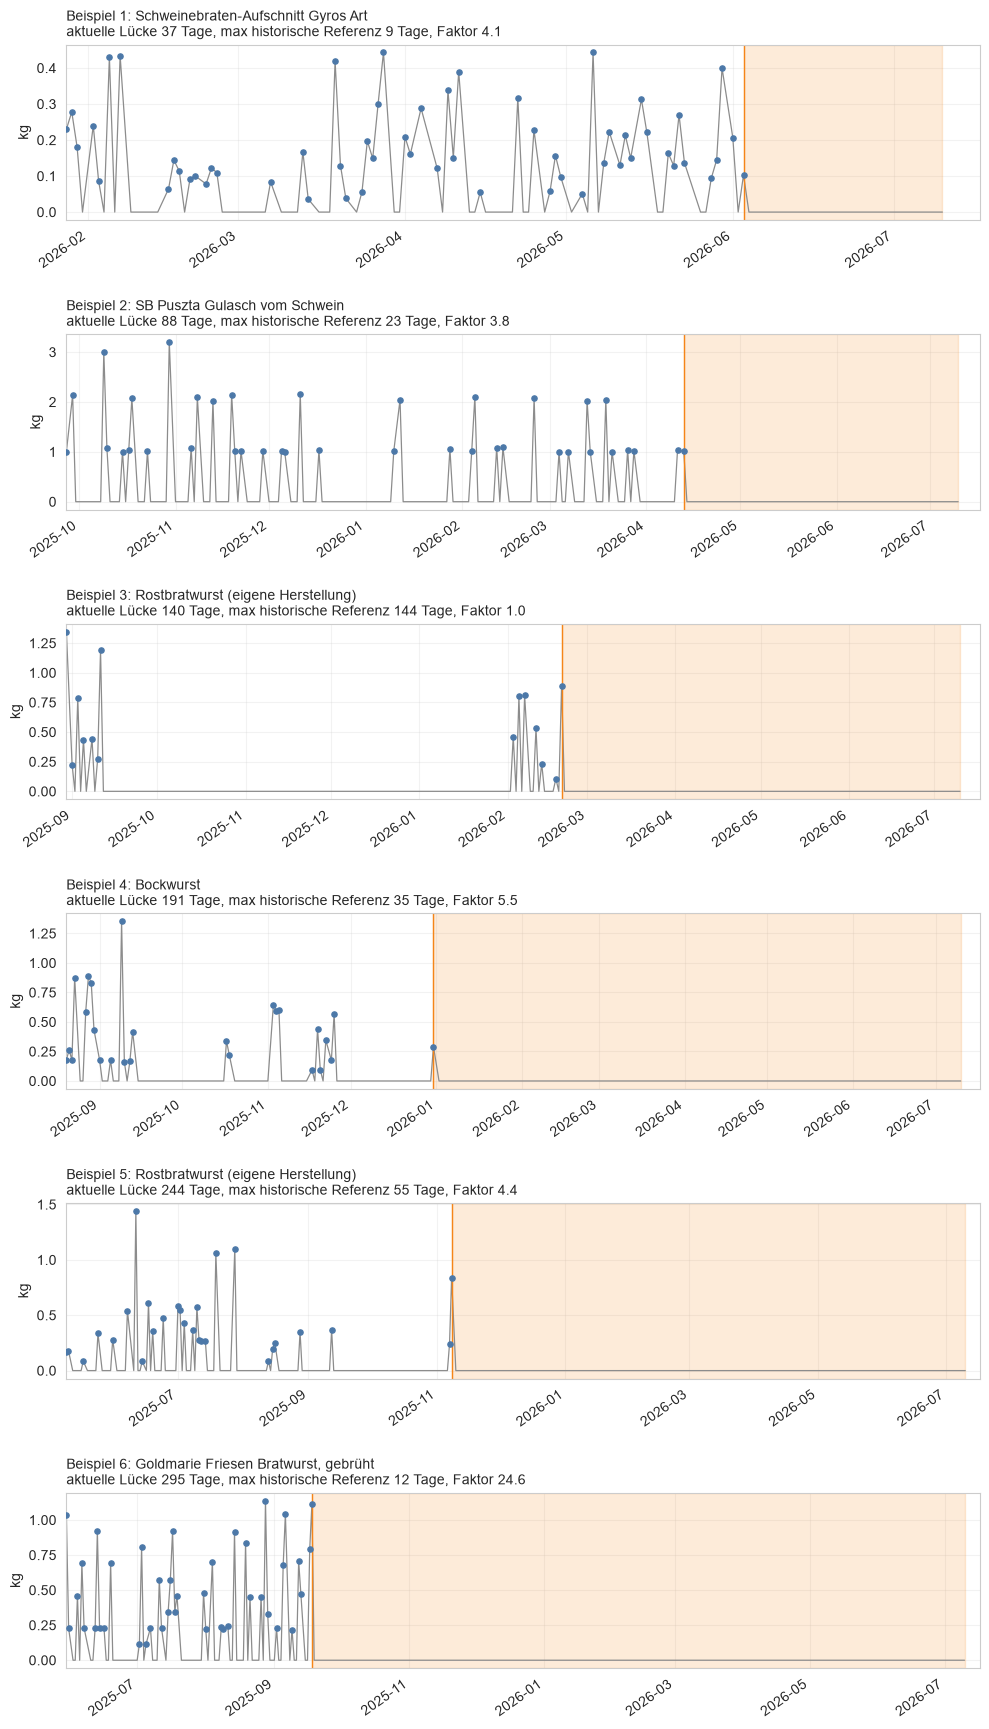

In [52]:
EXAMPLE_DATASET_NAME = "FCM täglich"
MIN_EXAMPLE_SALES_HISTORY_DAYS = 100
N_EXAMPLE_SERIES = 6
MIN_EXAMPLE_CURRENT_GAP_DISTANCE_DAYS = 20


def select_spaced_examples(candidates, n, min_gap_distance_days):
    candidates = candidates.sort_values("aktuelle_luecke_tage").reset_index(drop=True)
    if candidates.empty:
        return candidates

    target_gaps = np.linspace(
        candidates["aktuelle_luecke_tage"].min(),
        candidates["aktuelle_luecke_tage"].max(),
        min(n, len(candidates)),
    )
    selected_indices = []
    selected_gaps = []
    for target_gap in target_gaps:
        remaining = candidates.loc[~candidates.index.isin(selected_indices)].copy()
        spaced_remaining = remaining[
            remaining["aktuelle_luecke_tage"].apply(
                lambda gap: all(abs(gap - selected_gap) >= min_gap_distance_days for selected_gap in selected_gaps)
            )
        ]
        pool = spaced_remaining if not spaced_remaining.empty else remaining
        if pool.empty:
            break
        selected_index = (pool["aktuelle_luecke_tage"] - target_gap).abs().idxmin()
        selected_indices.append(selected_index)
        selected_gaps.append(candidates.loc[selected_index, "aktuelle_luecke_tage"])

    return candidates.loc[selected_indices].drop_duplicates(SERIES_COLUMNS).copy()


example_dataset = next(dataset for dataset in DATASETS if dataset["Datensatz"] == EXAMPLE_DATASET_NAME)
example_candidates = removed_series_by_dataset[EXAMPLE_DATASET_NAME].copy()
example_candidates = example_candidates[
    example_candidates["verkaufshistorie_tage"] >= MIN_EXAMPLE_SALES_HISTORY_DAYS
].copy()
example_series = select_spaced_examples(
    example_candidates,
    N_EXAMPLE_SERIES,
    MIN_EXAMPLE_CURRENT_GAP_DISTANCE_DAYS,
)
example_series["Beispiel"] = [f"Beispiel {idx + 1}" for idx in range(len(example_series))]

if example_series.empty:
    print("Keine entfernten Beispielreihen mit mindestens 100 Tagen Verkaufshistorie gefunden.")
else:
    con.register("example_keys", example_series[SERIES_COLUMNS])
    source = parquet_glob(example_dataset["Pfad"])
    example_daily = con.execute(
        f"""
        SELECT
            t.MARKT_ID,
            t.ARTIKEL_ID,
            CAST(t.DATE AS DATE) AS DATE,
            COALESCE(t.ABVERKAUFTE_MENGE_KG, 0.0)::DOUBLE AS Nachfrage_kg,
            t.ARTIKEL_BEZ
        FROM read_parquet('{source}') AS t
        INNER JOIN example_keys AS k
            ON t.MARKT_ID = k.MARKT_ID
           AND t.ARTIKEL_ID = k.ARTIKEL_ID
        WHERE t.DATE IS NOT NULL
        ORDER BY t.MARKT_ID, t.ARTIKEL_ID, t.DATE
        """
    ).fetchdf()
    con.unregister("example_keys")
    example_daily["DATE"] = pd.to_datetime(example_daily["DATE"])

    example_table = example_series[
        [
            "Beispiel",
            "MARKT_ID",
            "ARTIKEL_ID",
            "aktuelle_luecke_tage",
            "historische_referenz_luecke",
            "luecken_faktor",
            "Entfernungsgrund",
            "verkaufshistorie_tage",
            "nachfrageperioden",
        ]
    ].copy()
    display(example_table.style.format({
        "aktuelle_luecke_tage": "{:.0f}",
        "historische_referenz_luecke": "{:.0f}",
        "luecken_faktor": "{:.1f}",
        "verkaufshistorie_tage": "{:.0f}",
    }))

    fig, axes = plt.subplots(
        len(example_series),
        1,
        figsize=(10, 2.9 * len(example_series)),
        sharex=False,
    )
    if len(example_series) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, example_series.iterrows()):
        series = example_daily[
            (example_daily["MARKT_ID"] == row["MARKT_ID"])
            & (example_daily["ARTIKEL_ID"] == row["ARTIKEL_ID"])
        ].sort_values("DATE").copy()
        positive = series[series["Nachfrage_kg"] > 0]
        product_name = (
            series["ARTIKEL_BEZ"].dropna().iloc[0]
            if series["ARTIKEL_BEZ"].notna().any()
            else "Unbekanntes Produkt"
        )
        title = (
            f"{row['Beispiel']}: {product_name}\n"
            f"aktuelle Lücke {row['aktuelle_luecke_tage']:.0f} Tage, "
            f"max historische Referenz {row['historische_referenz_luecke']:.0f} Tage, "
            f"Faktor {row['luecken_faktor']:.1f}"
        )

        ax.plot(series["DATE"], series["Nachfrage_kg"], color="0.55", linewidth=0.9)
        ax.scatter(
            positive["DATE"],
            positive["Nachfrage_kg"],
            color="#4c78a8",
            s=14,
            zorder=3,
        )
        ax.axvspan(row["letzter_verkauf"], row["letzter_tag"], color="#f58518", alpha=0.16)
        ax.axvline(row["letzter_verkauf"], color="#f58518", linewidth=1.0)
        x_start = max(series["DATE"].min(), row["erster_verkauf"] - pd.Timedelta(days=7))
        x_end = row["letzter_tag"] + pd.Timedelta(days=7)
        ax.set_xlim(x_start, x_end)
        ax.set_title(title, fontsize=10, loc="left")
        ax.set_ylabel("kg")
        ax.tick_params(axis="x", labelrotation=35, labelbottom=True)
        plt.setp(ax.get_xticklabels(), ha="right")
        ax.grid(alpha=0.25)

    fig.tight_layout(h_pad=2.0)
    plt.show()
